# Einleitung
Im Rahmen des Data-Lab-Kurses wurde ein Machine-Learning‑Projekt entwickelt, das den praktischen Nutzen von Bildklassifikation im Kontext der Mülltrennung untersucht. Ziel des Projekts ist es, anhand von Bilddaten automatisiert zu erkennen, zu welcher Abfallkategorie ein Objekt gehört. Damit adressiert das Projekt ein reales Problem: Fehlwürfe im Abfall führen zu hohen Sortierkosten, mindern die Recyclingqualität und erschweren ressourceneffizientes Handeln. Ein KI‑gestütztes System könnte hier einen Beitrag leisten, indem es Nutzerinnen und Nutzer im Alltag unterstützt oder Sortierprozesse teilautomatisiert.
Ein zentraler Bestandteil des Projekts ist eine saubere und reproduzierbare Datenvorbereitung, die die Grundlage für jedes verlässliche Klassifikationsmodell bildet. Dieser Prozess umfasst die Sichtung, Analyse und Strukturierung des Datensatzes, das Vereinheitlichen der Bildgrößen, das Erstellen eines Train‑Validation‑Test‑Splits sowie das Generieren künstlich erweiterter Trainingsdaten durch Datenaugmentation. Durch diesen systematischen Workflow wurde ein qualitativ hochwertiger, konsistenter und modellfertiger Datensatz aufgebaut, der von der Modellgruppe zur Entwicklung eines neuronalen Klassifikators genutzt werden kann.
Damit leistet das Projekt nicht nur einen Beitrag zum Verständnis moderner Machine‑Learning‑Pipelines, sondern verbindet technische Methodenkompetenz mit einem gesellschaftlich relevanten Anwendungsfall.

# Anleitung
1. "Run all"
2. Zum Löschen der alten Ordner (damit wir sie in Schritt 6-8 (resizing, split, augmentation) neu laden können) in der Abfrage oben "j" eingeben
3. Warten bis das Programm durchgekaufen ist.

# 1. Setup & Bibliotheken

In diesem Schritt laden wir alle benötigten Bibliotheken

In [2]:
import os    #Zugriff auf Ordner, Dateien einlesen
import matplotlib.pyplot as plt     #Diagramme und Bilder anzeigen
from PIL import Image   #Bilder öffnen, bearbeiten, verarbeiten
import random
from collections import Counter
from sklearn.model_selection import train_test_split
import shutil

# 2. Projektpfad setzen und Datensatz prüfen

Wir setzen das Arbeitsverzeichnis auf unseren Projektordner und prüfen, ob der Ordner `dataset-original`gefunden wird.

In [3]:
# Name des Ordners, der gefunden werden muss
DATASET_DIR = "dataset-original"

def find_project_root(start_path):
    """
    Läuft vom gegebenen Startpfad nach oben,
    bis der Ordner 'dataset-original' gefunden wird.
    """
    current = start_path
    while True:
        if DATASET_DIR in os.listdir(current):
            return current
        # Eine Ebene höher gehen
        parent = os.path.dirname(current)
        if parent == current:
            # Root erreicht, nicht gefunden
            return None
        current = parent

# 1. Aktuellen Pfad anzeigen
print("Aktueller Arbeitsordner:", os.getcwd())

# 2. Projektordner automatisch suchen
project_root = find_project_root(os.getcwd())

if project_root is None:
    raise FileNotFoundError(f"'{DATASET_DIR}' konnte nicht gefunden werden.")

# 3. Arbeitsverzeichnis setzen (nur wenn nötig)
if os.getcwd() != project_root:
    os.chdir(project_root)
    print("Arbeitsverzeichnis automatisch gesetzt auf:", project_root)
else:
    print("Arbeitsverzeichnis war schon korrekt gesetzt.")

# 4. Finaler Check
print("dataset-original gefunden:", os.path.isdir(DATASET_DIR))
print("Inhalt:", os.listdir())

Aktueller Arbeitsordner: c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash\src
Arbeitsverzeichnis automatisch gesetzt auf: c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash
dataset-original gefunden: True
Inhalt: ['.git', 'dataset-224', 'dataset-augmented', 'dataset-original', 'dataset-split', 'README.md', 'requirements.txt', 'src']


# Löschen alter Ordner (Reset Code, bevor Bilder verarbeitet werden)
⭐ Richtige Reihenfolge – ganz einfach erklärt

🟩 1. ZUERST: Projektpfad automatisch setzen
Damit weiß der Kernel überhaupt, wo er sich befindet → sonst löscht er am falschen Ort!
✔ also zuerst:

automatisches Finden des Projektordners
os.chdir(...) → Arbeitsverzeichnis setzen
prüfen: dataset-original gefunden: True


🟩 2. DANN: automatische Ordner-Löschung (Reset)
Wenn der Projektpfad stimmt, kannst du gefahrlos löschen:

dataset-224
dataset-split
dataset-augmented

Warum erst jetzt?
Weil der Kernel zu diesem Zeitpunkt garantiert im richtigen Ordner ist — du löscht also nichts Falsches.

🟩 3. DANACH: Pipeline starten (Resize → Split → Augment)
Jetzt kannst du sicher:

Resizing, Split und Augmentation neu erstellen, ohne doppelte Ordner und ohne Fehler wie „Ordner nicht gefunden“, „dataset-224 ist leer“, „Split ist unvollständig“, „alte augmentierte Bilder wurden nicht überschrieben“

In [4]:
#Version fragt vorher nach
import shutil
import os
import stat


def handle_remove_readonly(func, path, exc):
    # Entsperrt schreibgeschützte Dateien/Ordner
    os.chmod(path, stat.S_IWRITE)
    func(path)

folders_to_reset = ["dataset-224", "dataset-split", "dataset-augmented"]

user_input = input("Ordner neu erzeugen? (j/n): ")

if user_input.lower() == "j":
    for folder in folders_to_reset:
        if os.path.exists(folder):
            shutil.rmtree(folder, onerror=handle_remove_readonly)
            print(f"Gelöscht: {folder}")
        else:
            print(f"Nicht vorhanden (ok): {folder}")
else:
    print("Reset übersprungen.")

Gelöscht: dataset-224
Gelöscht: dataset-split
Gelöscht: dataset-augmented


# 3. Klassen automatisch einlesen

Wir lesen die vorhandenen Klassen automatisch ein – dadurch bleibt der Workflow flexibel, falls neue Kategorien hinzukommen.

In [5]:
classes = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])


# 4. Beispielbilder anzeigen

Wir zeigen je Klasse einige Beispielbilder, um die Datenqualität zu prüfen.

Wir nutzen with Image.open() um das Bild nach Ende des Blocks zu schließen.
img.copy() erzeugt eine sichere Kopie im RAM, was perfekt für die Anzeige ist.

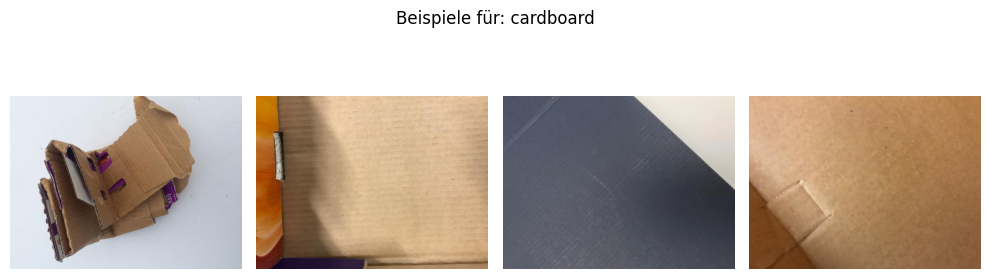

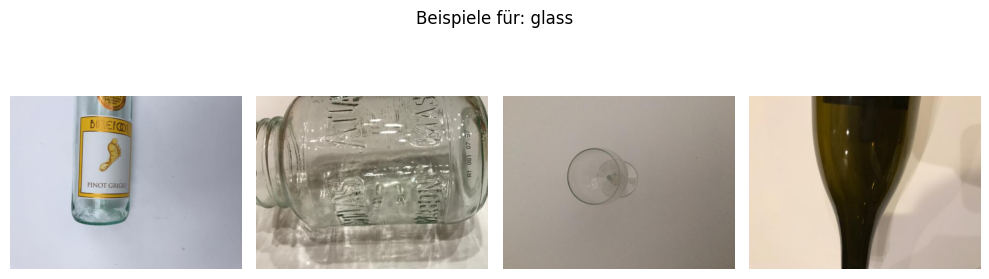

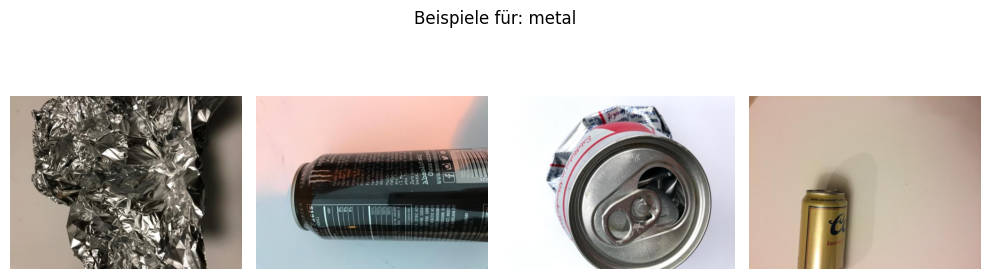

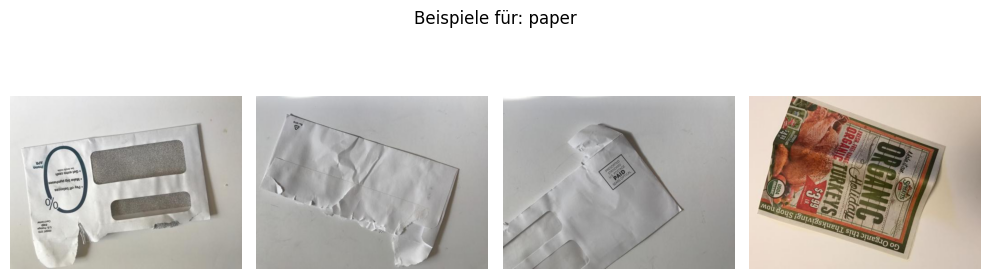

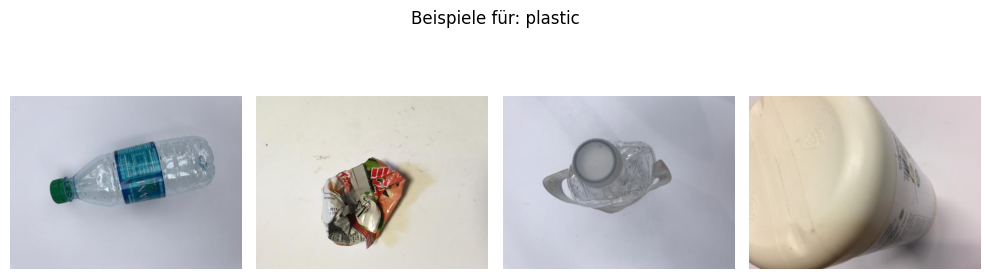

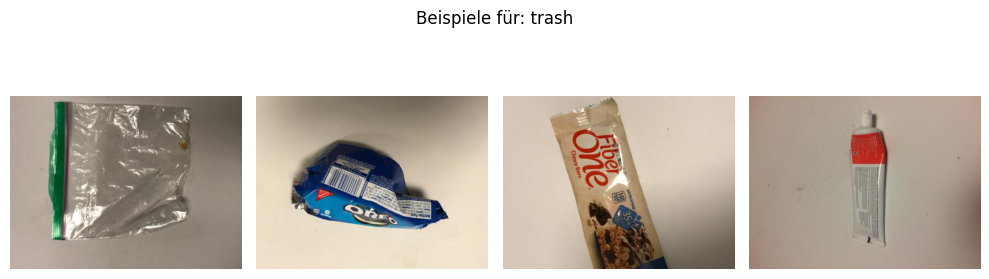

In [6]:
def show_examples(cls, n=4):
    folder = os.path.join(DATASET_DIR, cls)
    files = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(10, 3))

    for i, file in enumerate(files):
        img_path = os.path.join(folder, file)
        
        # Bild nur innerhalb des with-Kontextes öffnen, werden danach automatisch geschlossen
        with Image.open(img_path) as img:
            img = img.copy()  # wichtig, um geschlossene Datei nicht weiter zu nutzen
            
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(f"Beispiele für: {cls}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 4 Beispielbilder für alle Klassen anzeigen
for cls in classes:
    show_examples(cls, n=4)

# 5. Bildgrößen analysieren (optional)

Wir analysieren die Bildgrößen und die Häufigkeit der Bildgrößen. Das ist wichtig, bevor wir sie auf eine einheitliche Zielgröße (224×224) skalieren.

In [7]:
sizes = []

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        sizes.append(img.size)

Counter(sizes).most_common(10)

[((512, 384), 2527)]

<function matplotlib.pyplot.show(close=None, block=None)>

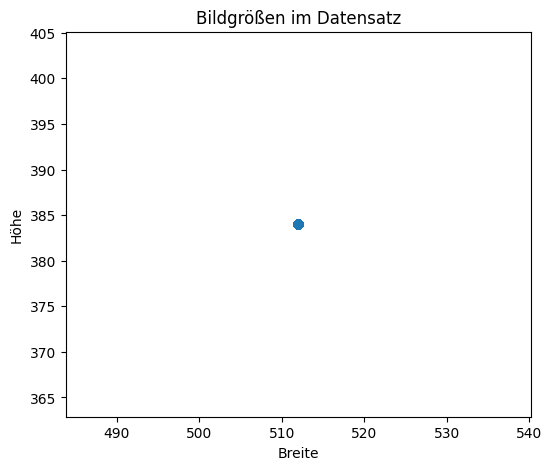

In [8]:
#Bildgrößen als Plot anzeigen
widths = [w for (w,h) in sizes]
heights = [h for (w,h) in sizes]

plt.figure(figsize=(6,5))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Breite")
plt.ylabel("Höhe")
plt.title("Bildgrößen im Datensatz")
plt.show

# 6. Resizing auf 224×224

Wir skalieren alle Bilder auf eine einheitliche Größe von 224×224 Pixeln und speichern sie im Ordner `dataset-224`.

In [9]:
#from PIL import Image
#import os

INPUT_DIR = "dataset-original"     # Originalbilder
OUTPUT_DIR = "dataset-224"        # Zielordner
TARGET_SIZE = (224, 224)          # Neue Bildgröße

# Zielordner erstellen
os.makedirs(OUTPUT_DIR, exist_ok=True)

for cls in classes:
    #Ordner für die Klassen im Zielverzeichnis anlegen
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    # Alle Bilder in der Klasse durchgehen
    for file in os.listdir(input_class):
        input_path = os.path.join(input_class, file)     #hier definieren wir input_path für das sichere öffnen der Bilde rmit if. Der Vorteil: Kein offenes File-Handle. Ordner lassen sich danach problemlos löschen.
        output_path = os.path.join(output_class, file)

        # Bild öffnen (sicher mit "with")
        with Image.open(input_path) as img:
            img = img.convert("RGB")        # Bild öffnen und konvertieren
            img = img.resize(TARGET_SIZE)   # Resizing durchführen
            img.save(output_path)           # Bild speichern

print("Resize abgeschlossen. Alle Bilder wurden nach dataset-224 resized.")


Resize abgeschlossen. Alle Bilder wurden nach dataset-224 resized.


# 7. Train/Validation/Test Split

Wir splitten den Datensatz in 70% Training, 15% Validation und 15% Test.

In [10]:
INPUT_DIR = "dataset-224"       # Eingangsordner (224 dataset)
OUTPUT_BASE = "dataset-split"   # Zielordner für Split

# Zielstruktur anlegen
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_BASE, split, cls), exist_ok=True)

# Anteile
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Jeden Klassenordner durchgehen
for cls in classes:
    files = os.listdir(os.path.join(INPUT_DIR, cls))
    
    # Train/Val/Test Split
    train_files, temp_files = train_test_split(
        files, test_size=(1-train_ratio), random_state=42
    )
    val_files, test_files = train_test_split(
        temp_files, test_size=(test_ratio/(test_ratio+val_ratio)), random_state=42
    )

    # Dateien verschieben
    for f in train_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "train", cls, f))
    for f in val_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "val", cls, f))
    for f in test_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "test", cls, f))

print("Split abgeschlossen!")

Split abgeschlossen!


In [11]:
#Prüfen, ob der Split funktioniert hat
for split in ["train", "val", "test"]:
    print(split)
    for cls in classes:
        count = len(os.listdir(os.path.join("dataset-split", split, cls)))
        print(f"  {cls}: {count} Bilder")

train
  cardboard: 282 Bilder
  glass: 350 Bilder
  metal: 286 Bilder
  paper: 415 Bilder
  plastic: 337 Bilder
  trash: 95 Bilder
val
  cardboard: 60 Bilder
  glass: 75 Bilder
  metal: 62 Bilder
  paper: 89 Bilder
  plastic: 72 Bilder
  trash: 21 Bilder
test
  cardboard: 61 Bilder
  glass: 76 Bilder
  metal: 62 Bilder
  paper: 90 Bilder
  plastic: 73 Bilder
  trash: 21 Bilder


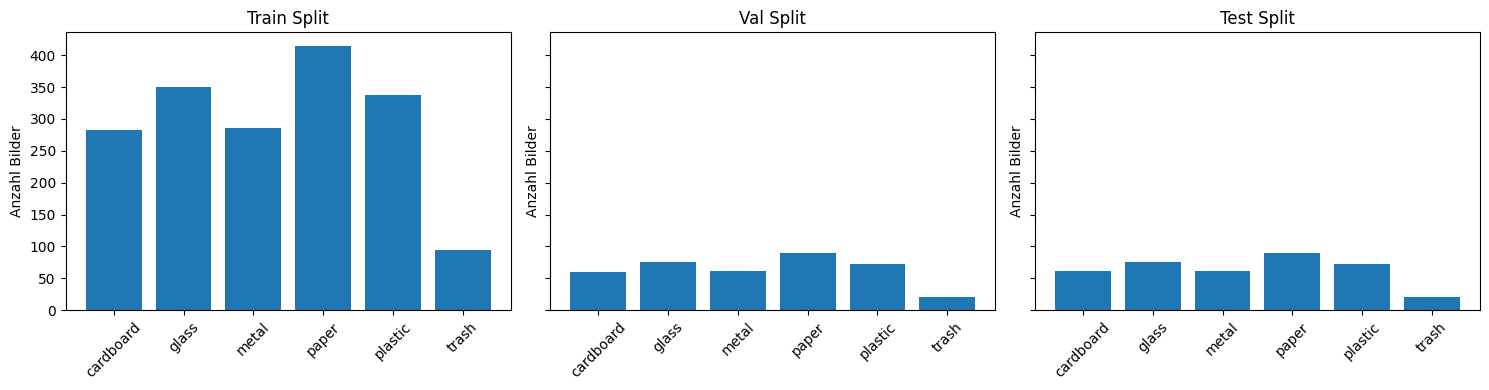

In [12]:
import matplotlib.pyplot as plt
import numpy as np

splits = ["train", "val", "test"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

x = np.arange(len(classes))  # feste Positionen für Balken

for i, split in enumerate(splits):
    counts = [len(os.listdir(os.path.join("dataset-split", split, cls))) for cls in classes]

    axes[i].bar(x, counts)
    axes[i].set_title(f"{split.capitalize()} Split")
    axes[i].set_ylabel("Anzahl Bilder")

    # Wichtig: erst die Tick-Positionen setzen...
    axes[i].set_xticks(x)
    # ...dann Labels → keine Warnung mehr
    axes[i].set_xticklabels(classes, rotation=45)

plt.tight_layout()
plt.show()


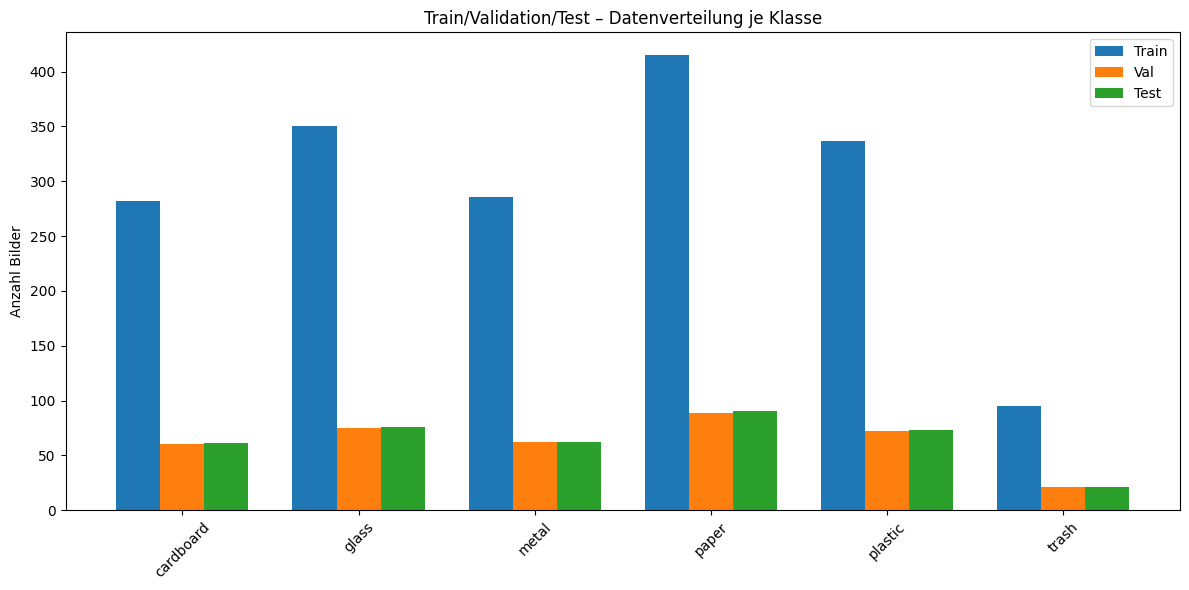

In [13]:
import numpy as np
import matplotlib.pyplot as plt

splits = ["train", "val", "test"]

# Counts je Klasse & je Split
split_counts = {
    split: [len(os.listdir(os.path.join("dataset-split", split, cls))) for cls in classes]
    for split in splits
}

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12, 6))
for i, split in enumerate(splits):
    plt.bar(x + i*width, split_counts[split], width=width, label=split.capitalize())

plt.xticks(x + width, classes, rotation=45)
plt.ylabel("Anzahl Bilder")
plt.title("Train/Validation/Test – Datenverteilung je Klasse")
plt.legend()
plt.tight_layout()
plt.show()


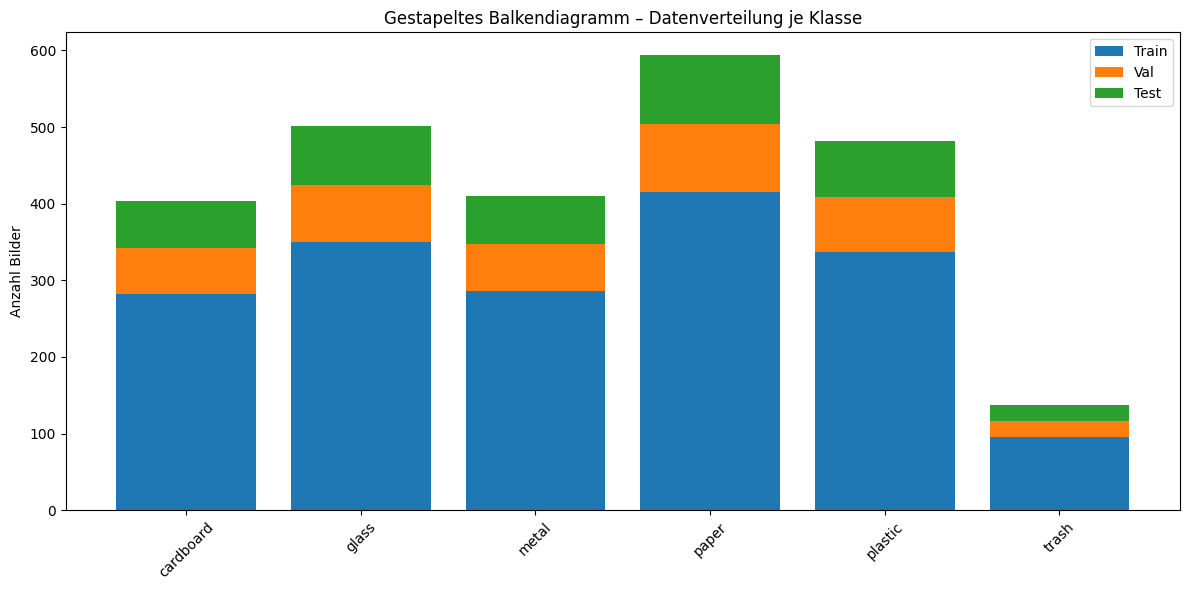

In [14]:
import matplotlib.pyplot as plt
import numpy as np

train_counts = [len(os.listdir(os.path.join("dataset-split/train", cls))) for cls in classes]
val_counts = [len(os.listdir(os.path.join("dataset-split/val", cls))) for cls in classes]
test_counts = [len(os.listdir(os.path.join("dataset-split/test", cls))) for cls in classes]

x = np.arange(len(classes))

plt.figure(figsize=(12,6))
plt.bar(x, train_counts, label="Train")
plt.bar(x, val_counts, bottom=train_counts, label="Val")
plt.bar(x, test_counts, bottom=np.array(train_counts)+np.array(val_counts), label="Test")

plt.xticks(x, classes, rotation=45)
plt.ylabel("Anzahl Bilder")
plt.title("Gestapeltes Balkendiagramm – Datenverteilung je Klasse")
plt.legend()
plt.tight_layout()
plt.show()

# 8. Datenaugmentation

Wir erweitern die Trainingsdaten um Rotation, Spiegelung und Helligkeits-/Kontrastvariationen.

In [15]:
from PIL import Image, ImageEnhance
import os
import random

INPUT_DIR = "dataset-split/train"
OUTPUT_DIR = "dataset-augmented/train"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def augment_image(img):
    if random.random() < 0.5:
        img = img.rotate(random.randint(-15, 15))
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() < 0.4:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
    if random.random() < 0.4:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))
    return img

for cls in classes:
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    files = os.listdir(input_class)
    print(f"{cls}: {len(files)} Trainingsbilder gefunden")

    for file in files:
        img_path = os.path.join(input_class, file)

        with Image.open(img_path) as img:
            img = img.convert("RGB")
            base_img = img.copy()

        # Original speichern
        base_img.save(os.path.join(output_class, file))

        # Zwei augmentierte Versionen speichern
        for i in range(2):
            aug = augment_image(base_img.copy())
            base, ext = os.path.splitext(file)
            aug.save(os.path.join(output_class, f"{base}_aug{i}{ext}"))

print("Augmentation fertig!")


cardboard: 282 Trainingsbilder gefunden
glass: 350 Trainingsbilder gefunden
metal: 286 Trainingsbilder gefunden
paper: 415 Trainingsbilder gefunden
plastic: 337 Trainingsbilder gefunden
trash: 95 Trainingsbilder gefunden
Augmentation fertig!


In [16]:
#Augmentation prüfen
for cls in classes:
    count = len(os.listdir(os.path.join("dataset-augmented/train", cls)))
    print(cls, ":", count)

cardboard : 846
glass : 1050
metal : 858
paper : 1245
plastic : 1011
trash : 285


# Fazit
Das durchgeführte Data‑Lab‑Projekt zeigt, wie wichtig eine strukturierte und transparente Datenvorbereitung für den Erfolg eines Machine‑Learning‑Modells ist. Durch die Vereinheitlichung der Bildgrößen, die gezielte Aufteilung in Trainings-, Validierungs- und Testmengen sowie die datenbasierte Erweiterung mittels Augmentation konnte ein belastbarer und vielseitiger Datensatz geschaffen werden. Dieser bildet die Grundlage für ein robustes neuronales Modell, das in der Lage ist, verschiedene Abfalltypen zuverlässig zu unterscheiden.
Darüber hinaus verdeutlicht das Projekt, dass Data‑Preparation weit mehr ist als ein technischer Zwischenschritt: Sie entscheidet maßgeblich über die Modellqualität, die Trainingsstabilität und die spätere Anwendbarkeit der KI. Die im Projekt durchlaufenen Schritte – Datenverständnis, Qualitätssicherung, Bereinigung, Transformation und Erweiterung – spiegeln zentrale Best Practices der modernen Datenwissenschaft wider und zeigen, wie theoretisches Wissen praktisch eingesetzt wird.
Durch den klaren Bezug zur realen Herausforderung der Mülltrennung wird zugleich sichtbar, wie Machine Learning konkrete gesellschaftliche Probleme adressieren kann. Das Projekt liefert damit nicht nur einen funktionierenden technischen Workflow, sondern auch ein Beispiel dafür, wie datengetriebene Lösungen Nachhaltigkeit und Alltagsprozesse unterstützen können.

dataset-augmented\train als trainingsdatensatz

dataset-split für Validierung und Test